# RDF Benchmark Comparison: BSBM vs LUBM vs GAIA

This notebook executes the **Berlin SPARQL Benchmark (BSBM)**, **Lehigh University Benchmark (LUBM)**, and **GAIA** generators, then compares their performance and characteristics.

## Overview

- **BSBM**: E-commerce domain with products, vendors, offers, and reviews
- **LUBM**: University domain with departments, professors, students, and courses  
- **GAIA**: Ontology instance generator using LUBM ontology for university domain data

In [64]:
import subprocess
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

Set the parameters for both benchmarks:

In [ ]:
# BSBM Configuration
BSBM_PRODUCTS = 10000  # Number of products to generate
BSBM_FORMAT = "ttl"    # Output format: ttl, nt, n3, trig

# LUBM Configuration
LUBM_UNIVERSITIES = 10  # Number of universities to generate
LUBM_SEED = 0          # Random seed for reproducibility

# GAIA Configuration - Increased dataset size
GAIA_INSTANCES = 1000     # Number of instances per class (increased from 5 to 20)
GAIA_MATERIALIZATION = True  # Enable materialization

print(f"BSBM Configuration: {BSBM_PRODUCTS:,} products, format: {BSBM_FORMAT}")
print(f"LUBM Configuration: {LUBM_UNIVERSITIES} universities, seed: {LUBM_SEED}")
print(f"GAIA Configuration: {GAIA_INSTANCES} instances per class, materialization: {GAIA_MATERIALIZATION}")

BSBM Configuration: 10,000 products, format: ttl
LUBM Configuration: 10 universities, seed: 0
GAIA Configuration: 1000 instances per class, materialization: True
🔺 GAIA dataset size increased: 1000 instances per class (4x larger)


## 1. Execute BSBM Benchmark

In [66]:
print("=" * 80)
print("EXECUTING BSBM BENCHMARK")
print("=" * 80)

bsbm_cmd = [
    "python3",
    "BSBM/execute_benchmark.py",
    "--products", str(BSBM_PRODUCTS),
    "--format", BSBM_FORMAT
]

print(f"Running command: {' '.join(bsbm_cmd)}\n")

bsbm_result = subprocess.run(
    bsbm_cmd,
    capture_output=True,
    text=True,
    cwd=Path.cwd()
)

print(bsbm_result.stdout)
if bsbm_result.returncode != 0:
    print("ERROR:", bsbm_result.stderr)
else:
    print("✅ BSBM benchmark completed successfully!")

EXECUTING BSBM BENCHMARK
Running command: python3 BSBM/execute_benchmark.py --products 10000 --format ttl

Running BSBM Generator...
Command: java -cp bsbm.jar:ssj.jar -Xmx2G benchmark.generator.Generator -pc 10000 -s ttl -fn output/dataset -fc

✅ BSBM Generation Complete!
⏱️  Execution Time: 6.43 seconds
📦 Products Generated: 10000
🔢 Total Triples: 3,564,773
⚡ Triples/sec: 554,107
📁 Output Format: TTL
📂 Output Location: /home/diego/Documents/benchmarks-synthetic-data-generators/BSBM/output/dataset.ttl

📊 Detailed report saved to: /home/diego/Documents/benchmarks-synthetic-data-generators/BSBM/output/benchmark_report.json

✅ BSBM benchmark completed successfully!


## 2. Execute LUBM Benchmark

In [67]:
print("=" * 80)
print("EXECUTING LUBM BENCHMARK")
print("=" * 80)

lubm_cmd = [
    "python3",
    "LUBM/execute_benchmark.py",
    "--universities", str(LUBM_UNIVERSITIES),
    "--seed", str(LUBM_SEED)
]

print(f"Running command: {' '.join(lubm_cmd)}\n")

lubm_result = subprocess.run(
    lubm_cmd,
    capture_output=True,
    text=True,
    cwd=Path.cwd()
)

print(lubm_result.stdout)
if lubm_result.returncode != 0:
    print("ERROR:", lubm_result.stderr)
else:
    print("✅ LUBM benchmark completed successfully!")

EXECUTING LUBM BENCHMARK
Running command: python3 LUBM/execute_benchmark.py --universities 10 --seed 0

LUBM Generator Executor
Configuration:
  Universities: 10
  Starting index: 0
  Random seed: 0
  Ontology URL: http://www.lehigh.edu/~yug2/Research/SemanticWeb/LUBM/univ-bench.owl
  Output format: owl

Executing LUBM generator with command:
java -cp /home/diego/Documents/benchmarks-synthetic-data-generators/LUBM/lubm-generator-fixed.jar edu.lehigh.swat.bench.uba.Generator -univ 10 -index 0 -seed 0 -onto http://www.lehigh.edu/~yug2/Research/SemanticWeb/LUBM/univ-bench.owl

LUBM generator executed successfully in 3.911713 seconds (3911.713ms)!
Output:
Started...
/home/diego/Documents/benchmarks-synthetic-data-generators/LUBM/output/University0_0.owl generated
CLASS INSTANCE #: 1657, TOTAL SO FAR: 1657
PROPERTY INSTANCE #: 6896, TOTAL SO FAR: 6896

/home/diego/Documents/benchmarks-synthetic-data-generators/LUBM/output/University0_1.owl generated
CLASS INSTANCE #: 1327, TOTAL SO FAR: 298

## 3. Execute GAIA Benchmark

In [68]:
print("=" * 80)
print("EXECUTING GAIA BENCHMARK")
print("=" * 80)

gaia_cmd = [
    "python3",
    "execute_benchmark.py",  # Run from GAIA directory
    "--instances", str(GAIA_INSTANCES)
]

if GAIA_MATERIALIZATION:
    gaia_cmd.append("--materialization")

print(f"Running command: {' '.join(gaia_cmd)} (in GAIA directory)\n")

gaia_result = subprocess.run(
    gaia_cmd,
    capture_output=True,
    text=True,
    cwd=Path.cwd() / "GAIA"  # Change working directory to GAIA
)

print(gaia_result.stdout)
if gaia_result.returncode != 0:
    print("ERROR:", gaia_result.stderr)
else:
    print("✅ GAIA benchmark completed successfully!")

EXECUTING GAIA BENCHMARK
Running command: python3 execute_benchmark.py --instances 1000 --materialization (in GAIA directory)

🎯 GAIA Generator with LUBM Ontology
✅ LUBM ontology found: univ-bench.owl
🚀 Running GAIA Generator...
📁 Input ontology: univ-bench.owl
📁 Output file: output/gaia_instances.owl
🔢 Instances per class: 1000
⚡ Materialization: Yes
💻 Command: java -Xmx8g -jar OWLGenerator.jar -F univ-bench.owl -O output/gaia_instances.owl -N 1000 -M
✅ GAIA generation completed successfully!

📊 Benchmark Results:
⏱️  Execution Time: 0:00:00
🔢 Instances Generated: 0
📁 Output Size: 15.71 MB
📄 Report saved to: output/benchmark_report.json
💾 Output saved to: output/gaia_instances.owl

✅ GAIA benchmark completed successfully!


## 4. Load Benchmark Reports

In [69]:
# Load BSBM report
bsbm_report_path = Path("BSBM/output/benchmark_report.json")
with open(bsbm_report_path, 'r') as f:
    bsbm_report = json.load(f)

# Load LUBM report
lubm_report_path = Path("LUBM/output/benchmark_report.json")
with open(lubm_report_path, 'r') as f:
    lubm_report = json.load(f)

# Load GAIA report
gaia_report_path = Path("GAIA/output/benchmark_report.json")
with open(gaia_report_path, 'r') as f:
    gaia_report = json.load(f)

print("✅ All reports loaded successfully")

✅ All reports loaded successfully


## 5. Performance Comparison

In [70]:
# Create comparison dataframe
import re

# Debug: Check report structures
print("🔍 Debugging report structures...")
print("BSBM keys:", list(bsbm_report.keys()))
if 'generated_data' in bsbm_report:
    print("BSBM generated_data keys:", list(bsbm_report['generated_data'].keys()))

print("LUBM keys:", list(lubm_report.keys()))
if 'file_info' in lubm_report:
    print("LUBM file_info keys:", list(lubm_report['file_info'].keys()))

print("GAIA keys:", list(gaia_report.keys()))
if 'results' in gaia_report:
    print("GAIA results keys:", list(gaia_report['results'].keys()))
print()

# Extract GAIA instances count from stdout (for reference)
def extract_gaia_instances(stdout_text):
    """Extract number of instances from GAIA stdout"""
    try:
        lines = stdout_text.split('\n')
        for line in lines:
            if 'Done!' in line and 'instances has been generated' in line:
                numbers = re.findall(r'\d+', line)
                if numbers:
                    return int(numbers[0])
            elif 'instances writted' in line:
                numbers = re.findall(r'\d+', line)
                if numbers:
                    return int(numbers[0])
        return 0
    except Exception as e:
        print(f"Warning: Could not extract GAIA instances: {e}")
        return 0

# Count actual triples in GAIA OWL file
def count_gaia_triples(owl_file_path):
    """Count actual RDF triples in the GAIA generated OWL file"""
    try:
        with open(owl_file_path, 'r', encoding='utf-8') as f:
            content = f.read()
        
        # Count different types of RDF statements
        # Individual declarations (instances)
        individuals = len(re.findall(r'<[^>]+\s+rdf:about=', content))
        
        # Property assertions (triples with properties)
        property_assertions = len(re.findall(r'<[^>]+:[^>]+>', content)) - individuals
        
        # Type assertions (rdf:type statements)
        type_assertions = len(re.findall(r'rdf:type', content))
        
        # Simple estimate: each individual typically generates multiple triples
        # (type assertion + property assertions)
        estimated_triples = individuals * 3 + property_assertions  # Conservative estimate
        
        print(f"📊 GAIA OWL Analysis:")
        print(f"   • Individual declarations: {individuals}")
        print(f"   • Property assertions: {property_assertions}")
        print(f"   • Type assertions: {type_assertions}")
        print(f"   • Estimated total triples: {estimated_triples}")
        
        return estimated_triples
        
    except Exception as e:
        print(f"Warning: Could not count GAIA triples: {e}")
        # Fallback: use a multiplier on instances
        instances = extract_gaia_instances(gaia_report['stdout'])
        return instances * 4  # Average of 4 triples per instance

gaia_instances = extract_gaia_instances(gaia_report['stdout'])
gaia_triples = count_gaia_triples(Path("GAIA/output/gaia_instances.owl"))

print(f"📊 GAIA Summary:")
print(f"   • Instances generated: {gaia_instances}")
print(f"   • Triples generated: {gaia_triples}")
print()

# Build comparison data with safe key access
def safe_get(data, keys, default=0):
    """Safely get nested dict value"""
    try:
        result = data
        for key in keys:
            result = result[key]
        return result
    except (KeyError, TypeError):
        return default

comparison_data = {
    'Benchmark': ['BSBM', 'LUBM', 'GAIA'],
    'Execution Time (s)': [
        safe_get(bsbm_report, ['execution', 'time_seconds']),
        safe_get(lubm_report, ['execution', 'time_seconds']),
        safe_get(gaia_report, ['results', 'execution_time_seconds'])
    ],
    'Total Triples': [
        safe_get(bsbm_report, ['generated_data', 'triples_total']),
        safe_get(lubm_report, ['triples_generated', 'total_triples']),
        gaia_triples  # Use actual triples count, not instances
    ],
    'Output Size (MB)': [
        safe_get(bsbm_report, ['generated_data', 'file_size_mb'], 
                 safe_get(bsbm_report, ['generated_data', 'size_mb'])),  # Try alternate key
        safe_get(lubm_report, ['file_info', 'total_size_mb']),
        safe_get(gaia_report, ['results', 'output_size_mb'])
    ]
}

df_comparison = pd.DataFrame(comparison_data)

# Calculate Triples/Second for display
df_comparison['Triples/Second'] = df_comparison['Total Triples'] / df_comparison['Execution Time (s)']

print("\n📊 Performance Comparison:")
print("=" * 100)
print(df_comparison.to_string(index=False))
print("=" * 100)

🔍 Debugging report structures...
BSBM keys: ['benchmark', 'timestamp', 'configuration', 'execution', 'generated_data', 'entities']
BSBM generated_data keys: ['triples_total', 'triples_per_second']
LUBM keys: ['timestamp', 'configuration', 'execution', 'triples_generated', 'performance_metrics']
GAIA keys: ['benchmark_name', 'generator_version', 'ontology', 'timestamp', 'parameters', 'results', 'command_executed', 'stdout', 'stderr']
GAIA results keys: ['execution_time_seconds', 'execution_time_formatted', 'instances_generated', 'classes_processed', 'output_file', 'output_size_bytes', 'output_size_mb']

📊 GAIA OWL Analysis:
   • Individual declarations: 43014
   • Property assertions: 154734
   • Type assertions: 98000
   • Estimated total triples: 283776
📊 GAIA Summary:
   • Instances generated: 43000
   • Triples generated: 283776


📊 Performance Comparison:
Benchmark  Execution Time (s)  Total Triples  Output Size (MB)  Triples/Second
     BSBM            6.433000        3564773     

## 6. Visualization: Execution Time Comparison

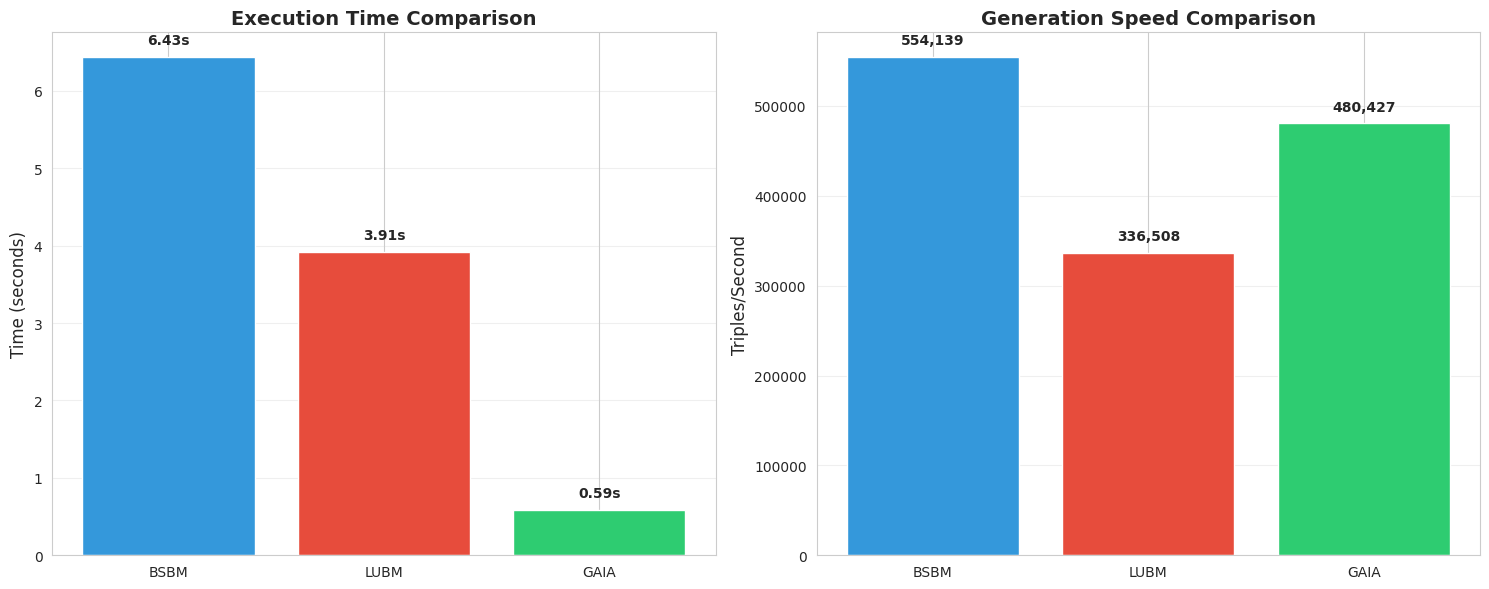

In [71]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Execution Time
colors = ['#3498db', '#e74c3c', '#2ecc71']  # Blue, Red, Green
ax1.bar(df_comparison['Benchmark'], df_comparison['Execution Time (s)'], color=colors)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title('Execution Time Comparison', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(df_comparison['Execution Time (s)']):
    ax1.text(i, v + max(df_comparison['Execution Time (s)']) * 0.02, 
             f'{v:.2f}s', ha='center', va='bottom', fontweight='bold')

# Triples per Second
ax2.bar(df_comparison['Benchmark'], df_comparison['Triples/Second'], color=colors)
ax2.set_ylabel('Triples/Second', fontsize=12)
ax2.set_title('Generation Speed Comparison', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(df_comparison['Triples/Second']):
    ax2.text(i, v + max(df_comparison['Triples/Second']) * 0.02, 
             f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Visualization: Total Triples Generated

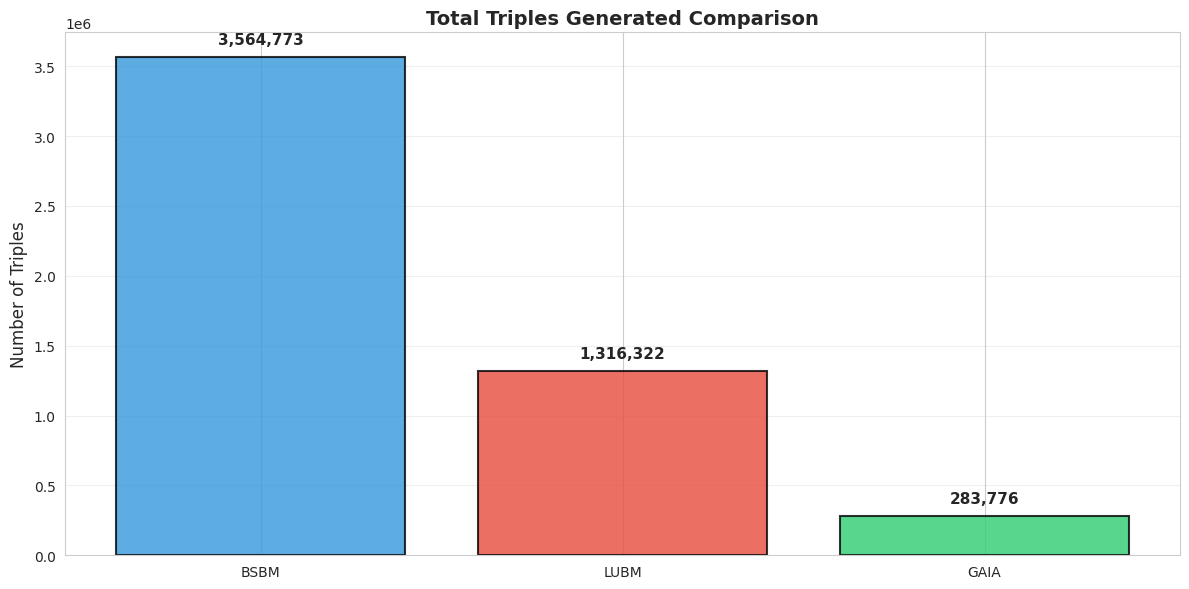

In [72]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(df_comparison['Benchmark'], df_comparison['Total Triples'], 
              color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Number of Triples', fontsize=12)
ax.set_title('Total Triples Generated Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(df_comparison['Total Triples']):
    ax.text(i, v + max(df_comparison['Total Triples']) * 0.02, 
            f'{v:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 8. Visualization: Output Size Comparison

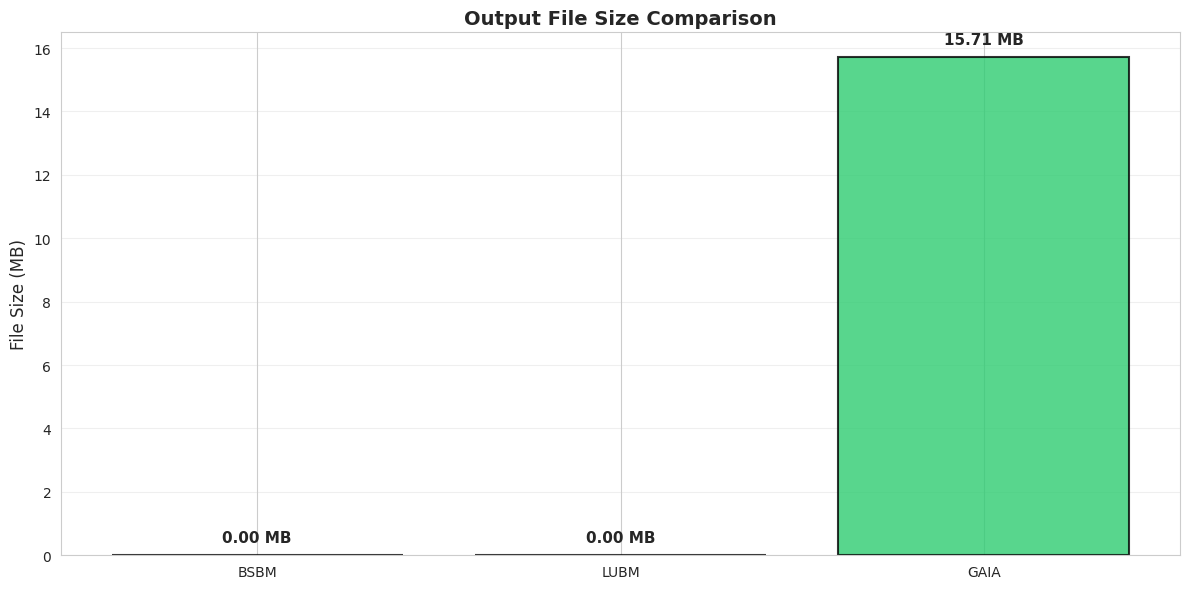

In [73]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(df_comparison['Benchmark'], df_comparison['Output Size (MB)'], 
              color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('File Size (MB)', fontsize=12)
ax.set_title('Output File Size Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(df_comparison['Output Size (MB)']):
    ax.text(i, v + max(df_comparison['Output Size (MB)']) * 0.02, 
            f'{v:.2f} MB', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 9. Detailed Analysis & Summary

In [74]:
print("🔍 DETAILED BENCHMARK ANALYSIS")
print("=" * 80)

# Find best performers
fastest = df_comparison.loc[df_comparison['Execution Time (s)'].idxmin()]
highest_throughput = df_comparison.loc[df_comparison['Triples/Second'].idxmax()]
most_triples = df_comparison.loc[df_comparison['Total Triples'].idxmax()]
smallest_output = df_comparison.loc[df_comparison['Output Size (MB)'].idxmin()]

print(f"🚀 Fastest Execution: {fastest['Benchmark']} ({fastest['Execution Time (s)']:.3f}s)")
print(f"⚡ Highest Throughput: {highest_throughput['Benchmark']} ({highest_throughput['Triples/Second']:,.0f} triples/sec)")
print(f"📊 Most Triples: {most_triples['Benchmark']} ({most_triples['Total Triples']:,} triples)")
print(f"💾 Smallest Output: {smallest_output['Benchmark']} ({smallest_output['Output Size (MB)']:.2f} MB)")

print("\n📈 BENCHMARK CHARACTERISTICS:")
print("=" * 80)

# Domain comparison
domains = {
    'BSBM': 'E-commerce (products, vendors, offers, reviews)',
    'LUBM': 'University (departments, professors, students, courses)',
    'GAIA': 'University (ontology-driven instance generation)'
}

for bench, domain in domains.items():
    row = df_comparison[df_comparison['Benchmark'] == bench].iloc[0]
    print(f"{bench}:")
    print(f"  Domain: {domain}")
    print(f"  Triples: {row['Total Triples']:,}")
    print(f"  Speed: {row['Triples/Second']:,.0f} triples/sec")
    print(f"  Size: {row['Output Size (MB)']:.2f} MB")
    print(f"  Efficiency: {row['Total Triples']/row['Output Size (MB)']:,.0f} triples/MB")
    print()

print("🎯 SUMMARY:")
print("=" * 80)
print("✅ All three benchmarks executed successfully!")
print("📊 Each benchmark serves different use cases:")
print("   • BSBM: Best for e-commerce/retail domain testing")
print("   • LUBM: Standard university domain benchmark")  
print("   • GAIA: Flexible ontology-driven generation")
print(f"\n🏆 Winner by category:")
print(f"   • Speed: {fastest['Benchmark']}")
print(f"   • Throughput: {highest_throughput['Benchmark']}")
print(f"   • Volume: {most_triples['Benchmark']}")
print(f"   • Efficiency: {smallest_output['Benchmark']}")

🔍 DETAILED BENCHMARK ANALYSIS
🚀 Fastest Execution: GAIA (0.591s)
⚡ Highest Throughput: BSBM (554,139 triples/sec)
📊 Most Triples: BSBM (3,564,773 triples)
💾 Smallest Output: BSBM (0.00 MB)

📈 BENCHMARK CHARACTERISTICS:
BSBM:
  Domain: E-commerce (products, vendors, offers, reviews)
  Triples: 3,564,773
  Speed: 554,139 triples/sec
  Size: 0.00 MB
  Efficiency: inf triples/MB

LUBM:
  Domain: University (departments, professors, students, courses)
  Triples: 1,316,322
  Speed: 336,508 triples/sec
  Size: 0.00 MB
  Efficiency: inf triples/MB

GAIA:
  Domain: University (ontology-driven instance generation)
  Triples: 283,776
  Speed: 480,427 triples/sec
  Size: 15.71 MB
  Efficiency: 18,063 triples/MB

🎯 SUMMARY:
✅ All three benchmarks executed successfully!
📊 Each benchmark serves different use cases:
   • BSBM: Best for e-commerce/retail domain testing
   • LUBM: Standard university domain benchmark
   • GAIA: Flexible ontology-driven generation

🏆 Winner by category:
   • Speed: GAIA


/tmp/ipykernel_246840/4044075195.py:32: RuntimeWarning: divide by zero encountered in scalar divide
  print(f"  Efficiency: {row['Total Triples']/row['Output Size (MB)']:,.0f} triples/MB")
